# Retail Store Sales - DataCleaning and EDA

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('retail_store_sales.csv')
df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [3]:
print(f'Number of rows is {df.shape[0]} , Number of Colums is {df.shape[1]}')

Number of rows is 12575 , Number of Colums is 11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [5]:
#Total Null values in each column
for i in df.columns:
    print(f'{i} : {df[i].isnull().sum()}')

Transaction ID : 0
Customer ID : 0
Category : 0
Item : 1213
Price Per Unit : 609
Quantity : 604
Total Spent : 604
Payment Method : 0
Location : 0
Transaction Date : 0
Discount Applied : 4199


## Data Cleaning


In [6]:
#changing datatype of columns
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Discount Applied'] = df['Discount Applied'].astype(bool)
df['Category'] = df['Category'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  category      
 3   Item              11362 non-null  object        
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  12575 non-null  bool          
dtypes: bool(1), category(1), datetime64[ns](1), float64(3), object(5)
memory usage: 909.2+ KB


In [7]:
#checking for duplicate rows
df.duplicated().sum()

np.int64(0)

Looking for Unique values in each column. this will also helps to find any invalid values




In [8]:
for i in df.columns:
    unique_values = df[i].unique()
    print(f'{i} : {unique_values}')

Transaction ID : ['TXN_6867343' 'TXN_3731986' 'TXN_9303719' ... 'TXN_5306010' 'TXN_5167298'
 'TXN_2407494']
Customer ID : ['CUST_09' 'CUST_22' 'CUST_02' 'CUST_06' 'CUST_05' 'CUST_07' 'CUST_21'
 'CUST_23' 'CUST_25' 'CUST_14' 'CUST_15' 'CUST_17' 'CUST_01' 'CUST_10'
 'CUST_04' 'CUST_13' 'CUST_18' 'CUST_08' 'CUST_20' 'CUST_12' 'CUST_11'
 'CUST_19' 'CUST_16' 'CUST_24' 'CUST_03']
Category : ['Patisserie', 'Milk Products', 'Butchers', 'Beverages', 'Food', 'Furniture', 'Electric household essentials', 'Computers and electric accessories']
Categories (8, object): ['Beverages', 'Butchers', 'Computers and electric accessories', 'Electric household essentials', 'Food', 'Furniture', 'Milk Products', 'Patisserie']
Item : ['Item_10_PAT' 'Item_17_MILK' 'Item_12_BUT' 'Item_16_BEV' 'Item_6_FOOD'
 nan 'Item_1_FOOD' 'Item_16_FUR' 'Item_22_BUT' 'Item_3_BUT' 'Item_2_FOOD'
 'Item_24_PAT' 'Item_16_MILK' 'Item_17_PAT' 'Item_13_EHE' 'Item_7_BEV'
 'Item_4_EHE' 'Item_10_FOOD' 'Item_14_FUR' 'Item_20_BUT' 'Item_25_


Lets Now fill the missing/Null values
1. For item column we will combine random number item + first 4 letters of the category
   

In [9]:
import random

item_list = [f"Item_{random.randint(1,30)}_{item[:4 if item in ['Food' , 'Milk Products' , 'Computers and electric accessories' , 'Electric household essentials']
    else 3].upper()}" for item in df[df['Item'].isna()]['Category'].to_list()]



In [10]:
df.loc[df['Item'].isna() , 'Item'] = item_list

2. Fill the price per unit column by dividing by total spend by quantity

In [11]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
#df.head(20)
#df['Price Per Unit'].isna() -> checking for null values if any in the column

3. Filling Total Spent column with Price Per Unit and Quantity

In [12]:
df['Total Spent'] = df['Total Spent'].fillna(df['Price Per Unit'] * df['Quantity'])

4. Filling Quantity with Price Per Unit and Total Spent

In [13]:
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])

In [14]:
#checking for null values 
df.isna().sum()

Transaction ID        0
Customer ID           0
Category              0
Item                  0
Price Per Unit        0
Quantity            604
Total Spent         604
Payment Method        0
Location              0
Transaction Date      0
Discount Applied      0
dtype: int64

In [15]:
#Remove 604 rows of quantity and total spent
df = df.dropna(subset = ['Quantity' , 'Total Spent'])
df.isna().sum().sum()

np.int64(0)

In [16]:
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,True
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,Item_5_PAT,20.0,10.0,200.0,Credit Card,Online,2023-11-30,True
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False
10,TXN_8776416,CUST_22,Butchers,Item_3_BUT,8.0,9.0,72.0,Cash,In-store,2024-12-14,True


In [17]:
#Extracting Year and Month
df.loc[:, 'Year'] = df['Transaction Date'].dt.year
df.loc[:, 'Month'] = df['Transaction Date'].dt.month
df.loc[:,'Year_Month'] = df['Transaction Date'].dt.strftime('%Y-%m')


In [18]:
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Year_Month
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,2024,4,2024-04
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,2023,7,2023-07
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,2022,10,2022-10
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,True,2022,5,2022-05
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,2022,10,2022-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,True,2023,9,2023-09
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False,2022,8,2022-08
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,True,2024,8,2024-08
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True,2023,12,2023-12


# Exploratory Data Analysis(EDA) 

### Sales & Revenue Insights

In [19]:
Category_Wise_Sales = df.groupby('Category' , observed = True)['Total Spent'].sum().sort_values(ascending=False)
Category_Wise_Sales

Category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: Total Spent, dtype: float64

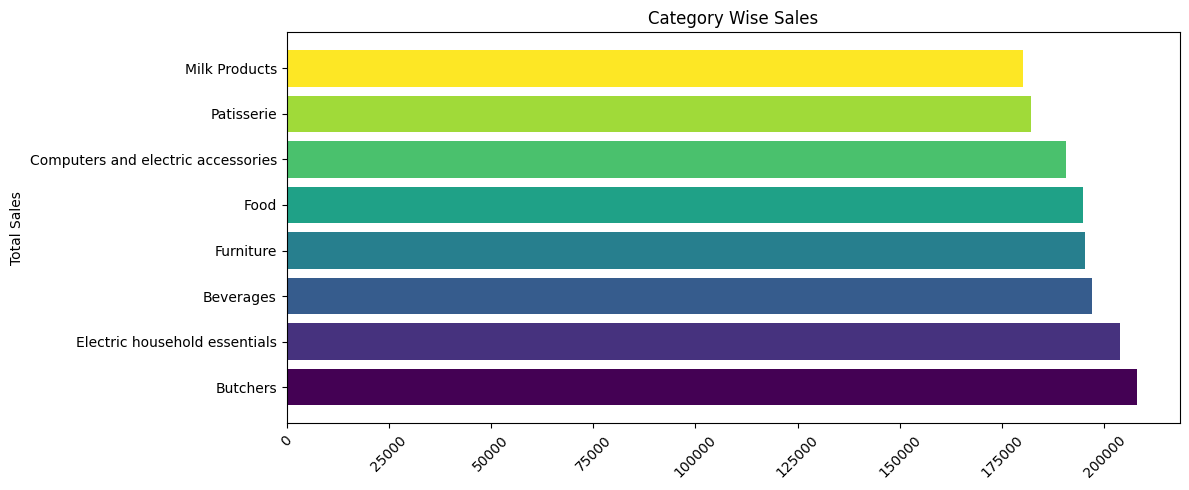

In [20]:
plt.figure(figsize=(12,5))

# create gradient colors
colors = plt.cm.viridis(np.linspace(0,1,len(Category_Wise_Sales)))

bars = plt.barh(Category_Wise_Sales.index,
               Category_Wise_Sales.values,
               color=colors)

plt.xticks(rotation=90)
plt.ylabel("Total Sales")
plt.title("Category Wise Sales")
plt.xticks(rotation = 45)


plt.tight_layout()
plt.show()

**Insights :**

* This analysis show the Categories Wise Sales. Butchers category generates the highest Revenue along with Electrice household essentials Overall, the chart highlights which Category contribute most to total revenue.

### Does Discount has any effect on sales

In [21]:
Highest_discount_applied = df.groupby('Discount Applied')['Total Spent'].sum().sort_values(ascending = False)
Highest_discount_applied

Discount Applied
True     1036936.0
False     515135.0
Name: Total Spent, dtype: float64

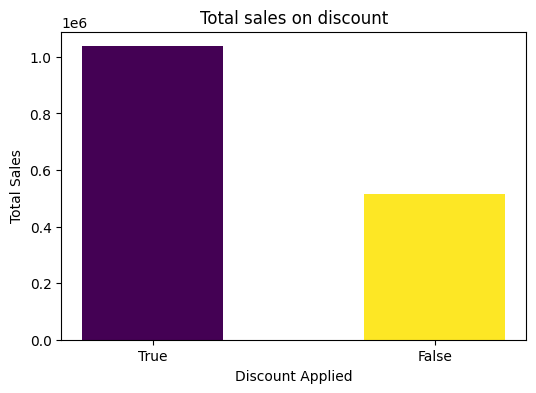

In [22]:
plt.figure(figsize = (6,4))

colors = plt.cm.viridis(np.linspace(0,1,len(Highest_discount_applied)))
labels = Highest_discount_applied.index.astype(str)
plt.bar(labels , Highest_discount_applied.values , color = colors , width = 0.5)
plt.title('Total sales on discount')
plt.ylabel('Total Sales')
plt.xlabel('Discount Applied')

plt.show()

**Insights :**
* Discounted transactions contribute more to total revenue than non-discounted transactions. However, this may be influenced by the higher number of discounted purchases rather than higher spending per transaction.

### Customers behaviour insights

**Top 10 High value customer based on Total spent**

In [23]:
High_value_customer = df.groupby('Customer ID')['Total Spent'].sum().sort_values(ascending = False)
High_value_customer.head(10)

Customer ID
CUST_24    68452.0
CUST_08    67351.5
CUST_05    66974.5
CUST_16    65570.5
CUST_13    65037.0
CUST_23    64507.0
CUST_10    63155.5
CUST_15    63117.5
CUST_21    62933.0
CUST_02    62046.5
Name: Total Spent, dtype: float64

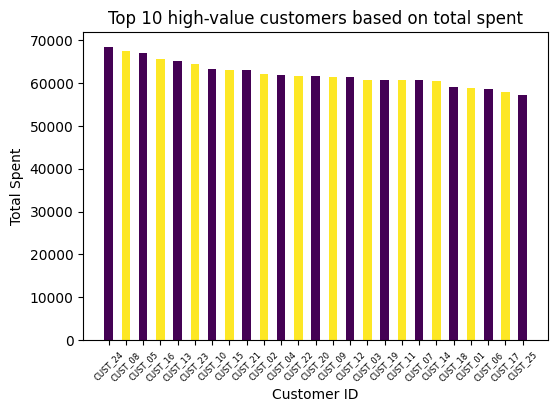

In [24]:
plt.figure(figsize = (6,4))

colors = plt.cm.viridis(np.linspace(0,1,len(Highest_discount_applied)))

plt.bar(High_value_customer.index , High_value_customer.values , color = colors , width = 0.5)
plt.title('Top 10 high-value customers based on total spent')
plt.ylabel('Total Spent')
plt.xlabel('Customer ID')
plt.xticks(rotation = 45 , fontsize = 6)

plt.show()

**Insights :**
* This analysis identifies the top 10 high-value customers based on total spending. Customer CUST_24 spent the most, followed closely by CUST_08 and CUST_05. The differences in spending among these top customers are relatively small, highlighting a group of customers who contribute significantly to total revenue.

### Distribution of Total spent by customers

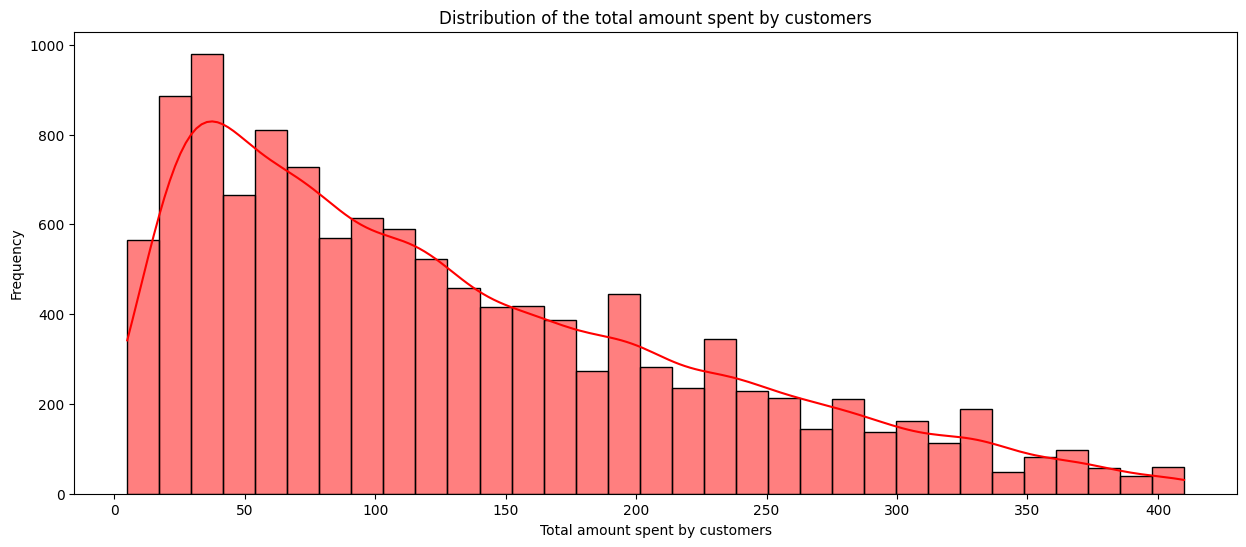

In [25]:
plt.figure(figsize=(15,6))

sns.histplot(df["Total Spent"],color="red",kde=True)

plt.xlabel("Total amount spent by customers")
plt.ylabel("Frequency")
plt.title("Distribution of the total amount spent by customers")

plt.show()

**Insights :**
* Most of the customers have spent a total amount spent of around 25.
* The total amount spent by customers ranges between 5 and 420, where most of the customers have spent more on the lower amount, and few have paid for higher total amounts.

### Number Of Payments made by each Payment method


In [26]:
pay_method = df.groupby('Payment Method')['Total Spent'].count()
pay_method

Payment Method
Cash              4103
Credit Card       3927
Digital Wallet    3941
Name: Total Spent, dtype: int64

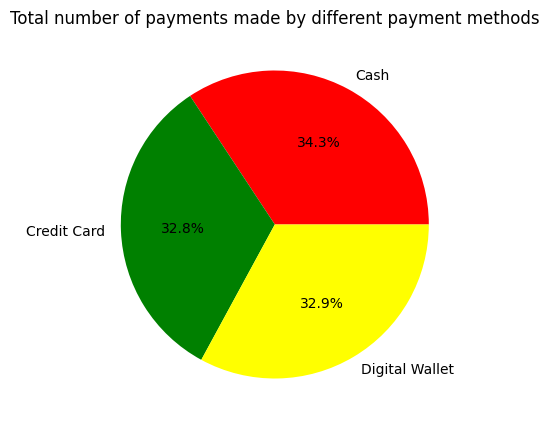

In [27]:
plt.figure(figsize=(7,5))

plt.pie(pay_method.values,
        labels=pay_method.index,
        colors=['red','green','yellow'],
        autopct='%1.1f%%')

plt.title("Total number of payments made by different payment methods")

plt.show()

**💡Insights :**
* Most of the customers have made the payment through cash in the retail store.

### Total number of purchases made by customers by location of purchase

In [28]:
purchase_loc = df.groupby('Location')['Location'].count()
purchase_loc

Location
In-store    5903
Online      6068
Name: Location, dtype: int64

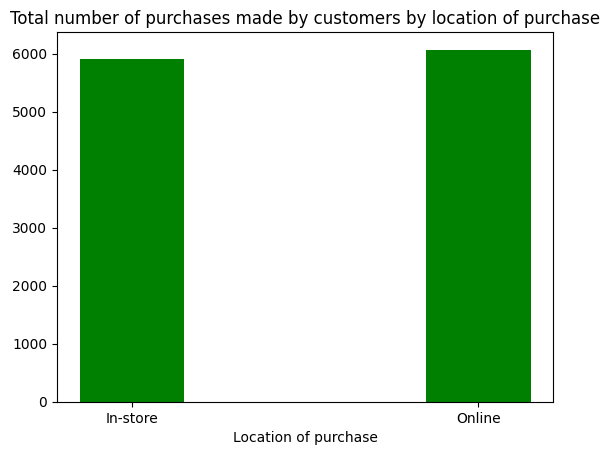

In [29]:

plt.bar(purchase_loc.index , purchase_loc.values , color = 'Green' , width = 0.3)
plt.xlabel("Location of purchase")
plt.title("Total number of purchases made by customers by location of purchase")

plt.show()

**💡Insights:**
* Most of the customers have purchased items from the retail store by online shopping.
* Around 6300 purchases are made through online shopping, and around 6000 purchases are in-store purchases.

### Distribution of the quantity of products purchased by customers

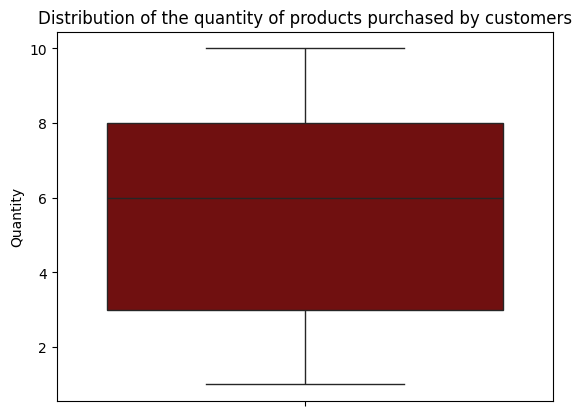

In [30]:
sns.boxplot(data=df,y="Quantity",color="maroon")
plt.ylabel("Quantity")
plt.title("Distribution of the quantity of products purchased by customers")
plt.show()

**💡Insights:**
* Most of the customers have purchased 3 to 8 quantities of items.
* The quantity of items purchased by the customers are ranging between 1 to 10.

### Distribution of Sales per year

In [31]:
sales_per_Year = df.groupby('Year')['Total Spent'].sum().sort_values(ascending = False)
sales_per_Year


Year
2024    524881.0
2022    510329.5
2023    491312.0
2025     25548.5
Name: Total Spent, dtype: float64

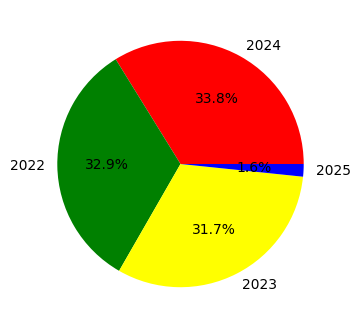

In [32]:
#plot
plt.figure(figsize = (7,4))
plt.pie(sales_per_Year.values , labels = sales_per_Year.index , colors = ['red','green','yellow', 'Blue'],
        autopct='%1.1f%%')
plt.show()

**💡Insights :**
* The year 2025 had less purchases in the retail store of 1.7%.
* Most of the sales happened in the year 2024 with a percentage of 33.7.

### Total Purchase by month

In [33]:
t_pur = df.groupby(df['Transaction Date'].dt.month_name())['Transaction Date'].count()
t_pur

Transaction Date
April         953
August        992
December      974
February      916
January      1295
July         1039
June          991
March         965
May           978
November      950
October       934
September     984
Name: Transaction Date, dtype: int64

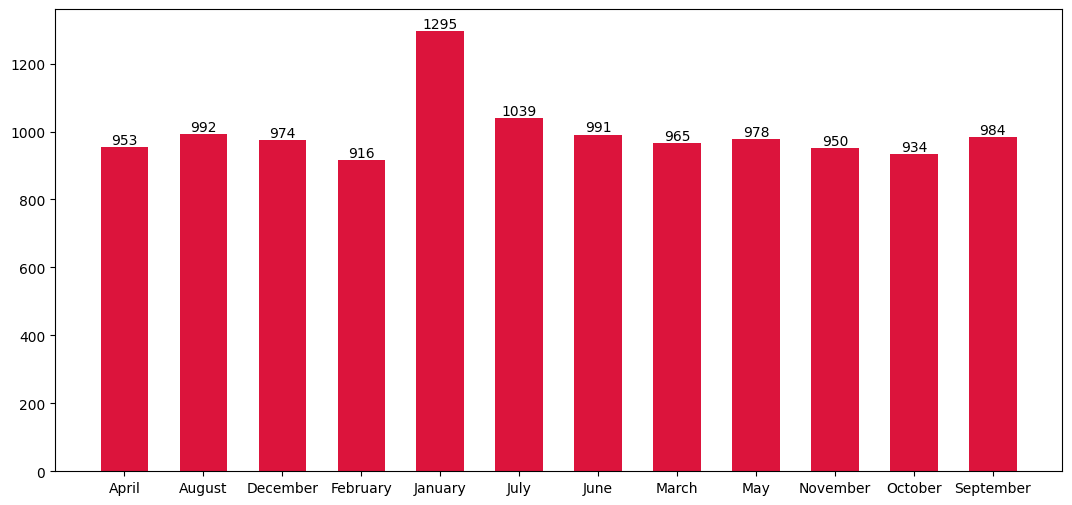

In [34]:
plt.figure(figsize = (13,6))
bars = plt.bar(t_pur.index,t_pur.values , color = 'crimson' , width = 0.6)
plt.bar_label(bars)
plt.show()

**💡Insights:**
* January had the highest number of purchases made by customers followed by July.
* February and October had the lowest number of purchases.

### Total amount spent by price per unit

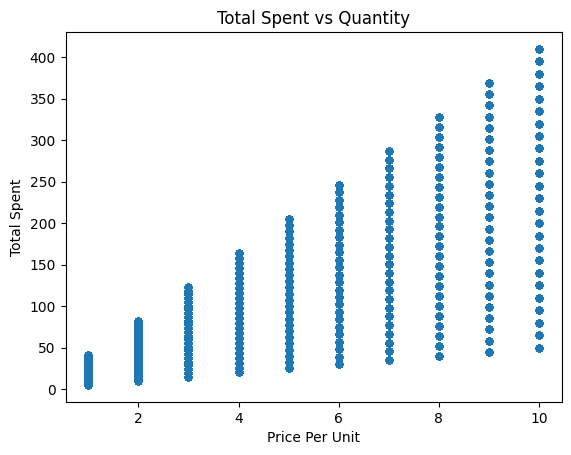

In [35]:
plt.scatter( df['Quantity'] , df['Total Spent'] , s= 20)

plt.ylabel("Total Spent")
plt.xlabel("Price Per Unit")

plt.title("Total Spent vs Quantity")

plt.show()

**💡Insights:**
* The total amount spent by customers is increasing with the price per unit of the items in all categories in the retail store.

### Total count of Categories purchased by customers

In [36]:
cat_count = df.groupby('Category' , observed = True)['Category'].count()
cat_count

Category
Beverages                             1496
Butchers                              1496
Computers and electric accessories    1477
Electric household essentials         1516
Food                                  1507
Furniture                             1525
Milk Products                         1513
Patisserie                            1441
Name: Category, dtype: int64

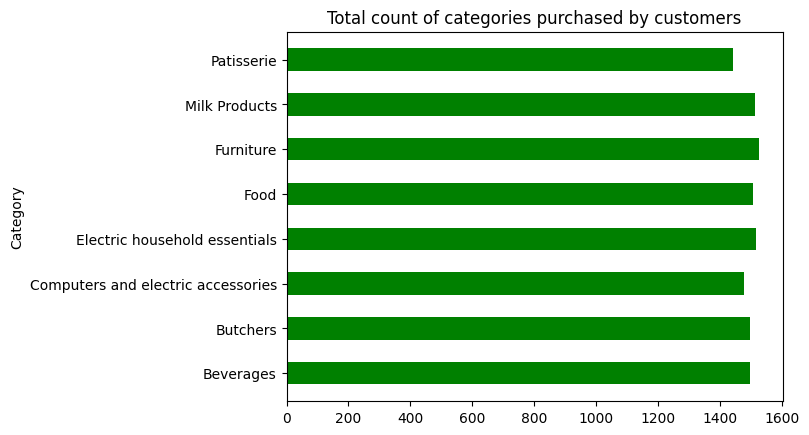

In [37]:
plt.barh(cat_count.index,cat_count.values , color="green" , height = 0.5)
plt.title("Total count of categories purchased by customers")
plt.ylabel("Category")
plt.show()

**💡Insights:**
* Milk products, food, furniture, and electric household essentials are the categories which had the highest number of sales which is around 1600.

### Comparison of payment methods used for Online and In-store purchases

In [38]:
# Table for Online payments
online_df = df[df['Location'] == 'Online']
online_table = online_df['Payment Method'].value_counts().reset_index()
online_table.columns = ['Payment Method', 'Online Count']

# Table for Offline payments
offline_df = df[df['Location'] == 'In-store']
offline_table = offline_df['Payment Method'].value_counts().reset_index()
offline_table.columns = ['Payment Method', 'Offline Count']

# Merge tables side by side
side_by_side = pd.merge(online_table, offline_table, on='Payment Method', how='outer').fillna(0)
side_by_side

,Payment Method,Online Count,Offline Count
0,Cash,2071,2032
1,Credit Card,2009,1918
2,Digital Wallet,1988,1953


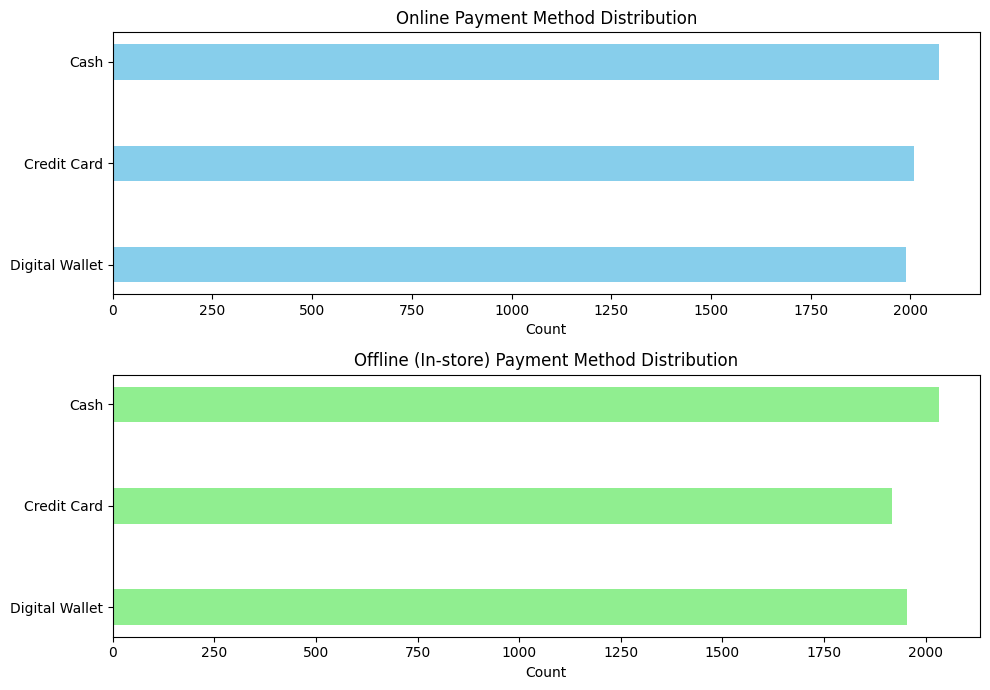

In [41]:
# Set figure size
plt.figure(figsize=(10, 7))

# ----------------- Online Payment Chart -----------------
plt.subplot(2, 1, 1)  # 2 rows, 1 column, chart 1 (top)
plt.barh(side_by_side['Payment Method'], side_by_side['Online Count'], color='skyblue' , height = 0.35)
plt.xlabel('Count')
plt.title('Online Payment Method Distribution')
plt.gca().invert_yaxis()  # highest count on top

# ----------------- Offline Payment Chart -----------------
plt.subplot(2, 1, 2)  # 2 rows, 1 column, chart 2 (bottom)
plt.barh(side_by_side['Payment Method'], side_by_side['Offline Count'], color='lightgreen' , height = 0.35)
plt.xlabel('Count')
plt.title('Offline (In-store) Payment Method Distribution')
plt.gca().invert_yaxis()  # align with Online chart

plt.tight_layout()
plt.show()

**💡Insights:**
* Cash payment is the most sought-after mode of payment for both online and in-store purchases in the retail store.
* Most of the customers who made online purchases have made payment through credit card as their second choice other than digital wallet.
* Digital wallet is the second most used payment method for in-store purchases.

### Best selling category per month

In [43]:
best_selling_cat = df.groupby(["Category","Month"] , observed = True)["Total Spent"].sum()
best_selling_cat

Category    Month
Beverages   1        21834.0
            2        17136.5
            3        15127.0
            4        13029.0
            5        17169.0
                      ...   
Patisserie  8        14875.5
            9        14434.5
            10       15212.5
            11       12706.5
            12       15446.5
Name: Total Spent, Length: 96, dtype: float64

Month
1     142.784091
2     152.833333
3     135.482609
4     148.176991
5     147.790179
6     140.665323
7     144.697479
8     131.734127
9     143.038793
10    143.283784
11    143.487805
12    160.153061
dtype: float64

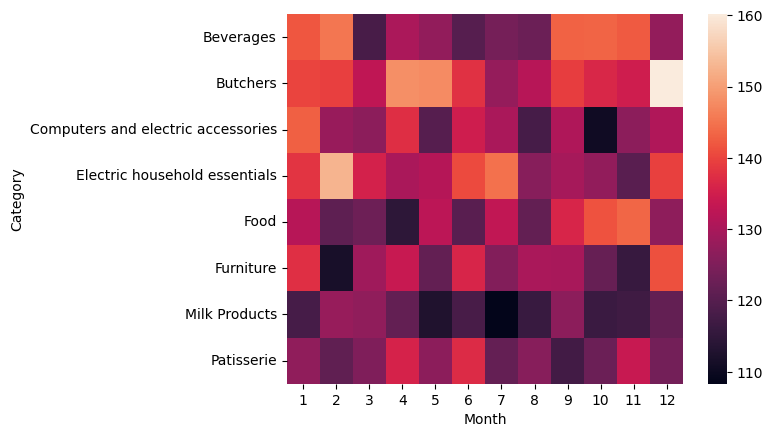

In [46]:
pivot = df.pivot_table(values="Total Spent", index="Category", columns="Month" , observed = True)
sns.heatmap(pivot)
pivot.max(axis=1) 
pivot.max(axis=0) 


**Insights**
* Categories like Butchers and Beverages drive most revenue.
* December is the peak month for multiple categories, likely seasonal effect.
* Milk Products and Patisserie are consistently low revenue categories.
* Some categories show seasonal spikes (Furniture, Electric essentials).

Text(0.5, 1.0, 'Correlation Heatmap of transaction variables')

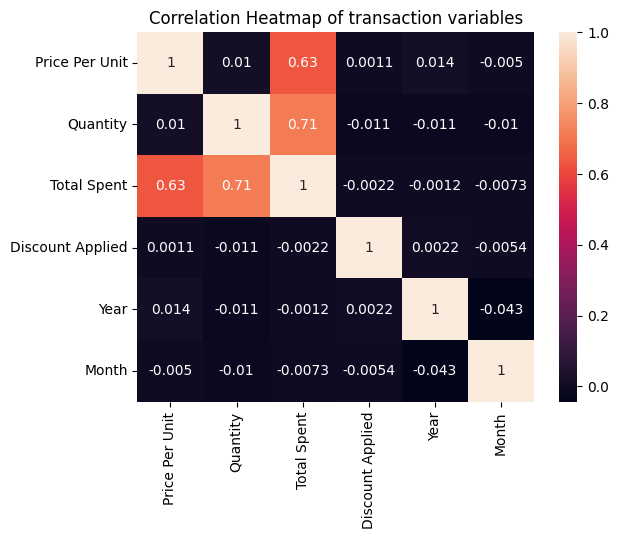

In [50]:
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix,annot=True)
plt.title("Correlation Heatmap of transaction variables")

**💡Insights:**
* A strong positive correlation exists between the quantity of items purchased and the total amount spent on the purchase, indicating that higher * * * quantities contribute to higher spending by customers.
* A moderative positive correlation exists between the price per unit and the total amount spent by customers, indicating that increasing the total * * amount spent depends on the increasing price per unit.
* The quantity and price per unit have a weak correlation indicating that price per unit does not affect most of the quantity of items purchased by customers.
* No correlation between day of transaction and other variables like total amount spent, quantity, price per unit, and year of transaction.
* The year of transaction does not affect the total amount spent and quantity, as it has a negative weak correlation.

### Total amount spent on categories by year of purchase

**1. Butchers**

Text(0.5, 1.0, 'Total amount spent on Butchers by year of purchase')

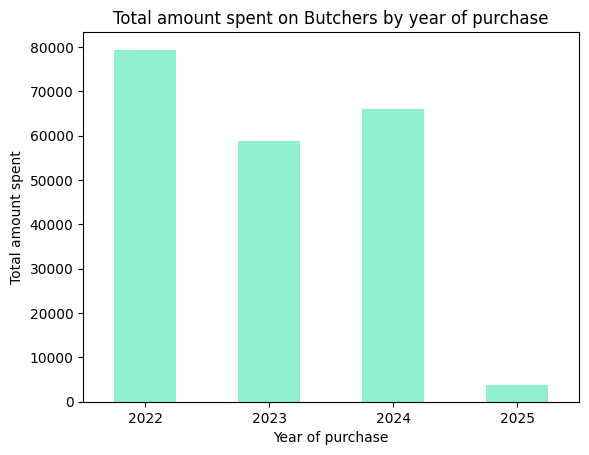

In [57]:
sns.barplot(x=df[(df["Category"]=="Butchers")].groupby("Year")["Total Spent"].sum().index,y=df[(df["Category"]=="Butchers")].groupby("Year")["Total Spent"].sum().values,width=0.5,color="aquamarine")
plt.xlabel("Year of purchase")
plt.ylabel("Total amount spent")
plt.title("Total amount spent on Butchers by year of purchase")

**💡Insights:**
* The total amount spent on Butchers in 2022 is higher than the year 2023 and 2024.
* 2025 has the lowest total amount spent on Butchers, which is around 2500.

**2. Beverages**

Text(0.5, 1.0, 'Total amount spent on  Beverages by year of purchase')

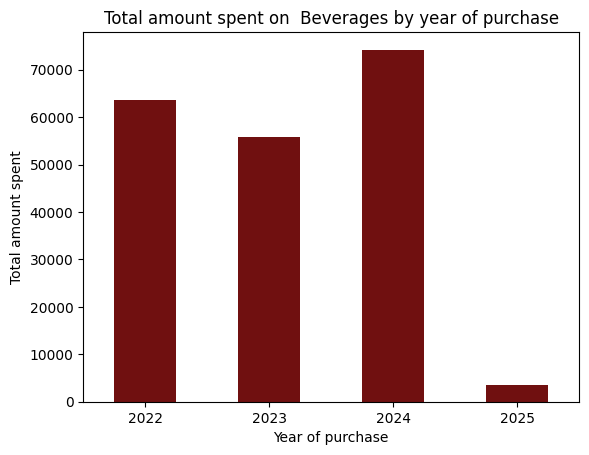

In [59]:
sns.barplot(x=df[(df["Category"]=="Beverages")].groupby("Year")["Total Spent"].sum().index,y=df[(df["Category"]=="Beverages")].groupby("Year")["Total Spent"].sum().values,width=0.5,color="Maroon")
plt.xlabel("Year of purchase")
plt.ylabel("Total amount spent")
plt.title("Total amount spent on  Beverages by year of purchase")

**💡Insights:**

* The total amount spent on Beverages in 2024 is higher than the year 2023 and 2022.
* 2025 has the lowest total amount spent on Beverages, which is around 2500.

3. Computers and electric accessories 

Text(0.5, 1.0, 'Total amount spent on  Computers and electric accessories by year of purchase')

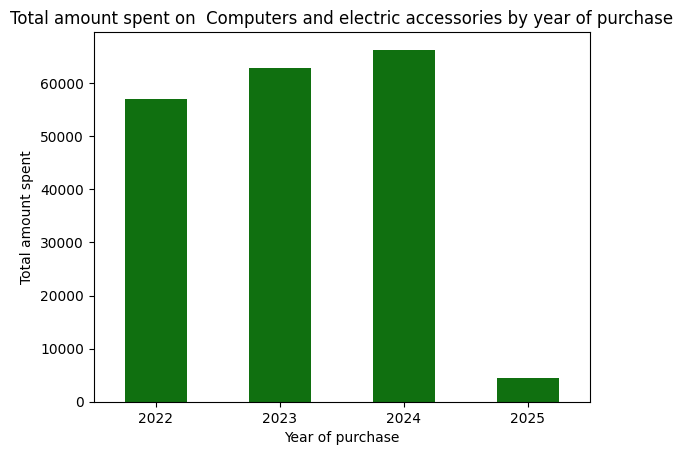

In [63]:
sns.barplot(x=df[(df["Category"]=="Computers and electric accessories")].groupby("Year")["Total Spent"].sum().index,y=df[(df["Category"]=="Computers and electric accessories")].groupby("Year")["Total Spent"].sum().values,width=0.5,color="Green")
plt.xlabel("Year of purchase")
plt.ylabel("Total amount spent")
plt.title("Total amount spent on  Computers and electric accessories by year of purchase")

**💡Insights:**

* The total amount spent on Computers and electric accessories in 2024 is higher than the year 2023 Then in 2022.
* 2025 has the lowest total amount spent on Computers and electric accessories, which is around 2500.

4. Electric household essentials

Text(0.5, 1.0, 'Total amount spent on  Electric household essentials by year of purchase')

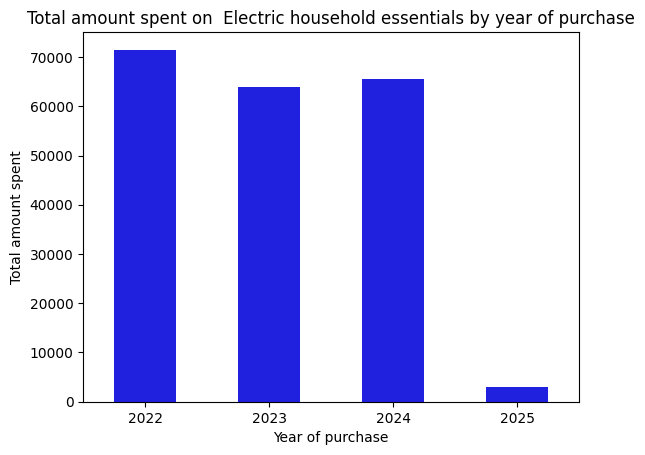

In [64]:
sns.barplot(x=df[(df["Category"]=="Electric household essentials")].groupby("Year")["Total Spent"].sum().index,y=df[(df["Category"]=="Electric household essentials")].groupby("Year")["Total Spent"].sum().values,width=0.5,color="blue")
plt.xlabel("Year of purchase")
plt.ylabel("Total amount spent")
plt.title("Total amount spent on  Electric household essentials by year of purchase")

**💡Insights:**

* The total amount spent on Electric household essentials in 2022 is higher than the year 2023 and 2022.
* 2025 has the lowest total amount spent on Electric household essentials , which is around 2000.

5. Food 

Text(0.5, 1.0, 'Total amount spent on Food by year of purchase')

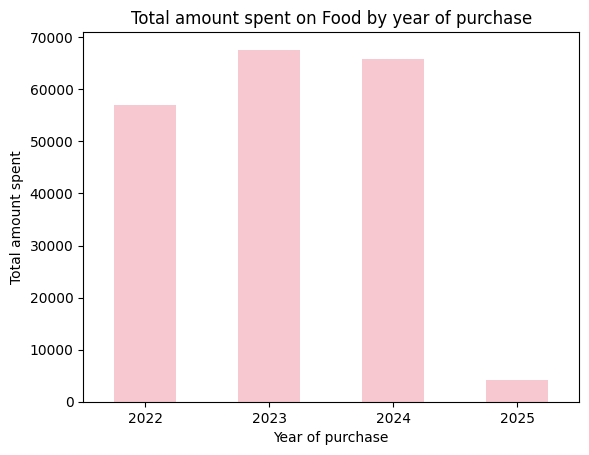

In [66]:
sns.barplot(x=df[(df["Category"]=="Food")].groupby("Year")["Total Spent"].sum().index,y=df[(df["Category"]=="Food")].groupby("Year")["Total Spent"].sum().values,width=0.5,color="Pink")
plt.xlabel("Year of purchase")
plt.ylabel("Total amount spent")
plt.title("Total amount spent on Food by year of purchase")

**💡Insights:**

* The total amount spent on Food in 2023 is higher than the year 2024 and 2022.
* 2025 has the lowest total amount spent on Food, which is around 2500.

5. Furniture

Text(0.5, 1.0, 'Total amount spent on Furniture by year of purchase')

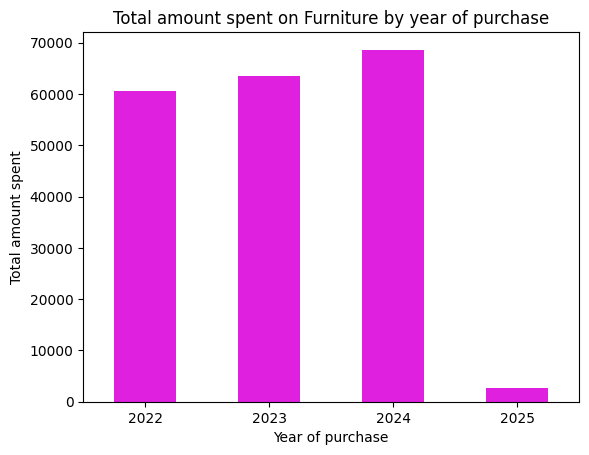

In [71]:
sns.barplot(x=df[(df["Category"]=="Furniture")].groupby("Year")["Total Spent"].sum().index,y=df[(df["Category"]=="Furniture")].groupby("Year")["Total Spent"].sum().values,width=0.5,color="Magenta")
plt.xlabel("Year of purchase")
plt.ylabel("Total amount spent")
plt.title("Total amount spent on Furniture by year of purchase")

**💡Insights:**

* The total amount spent on Furniture in 2024 is higher than the year 2022 Then in 2023.
* 2025 has the lowest total amount spent on Furniture, which is around 2000.

6. Milk Products 

Text(0.5, 1.0, 'Total amount spent on Milk Products  by year of purchase')

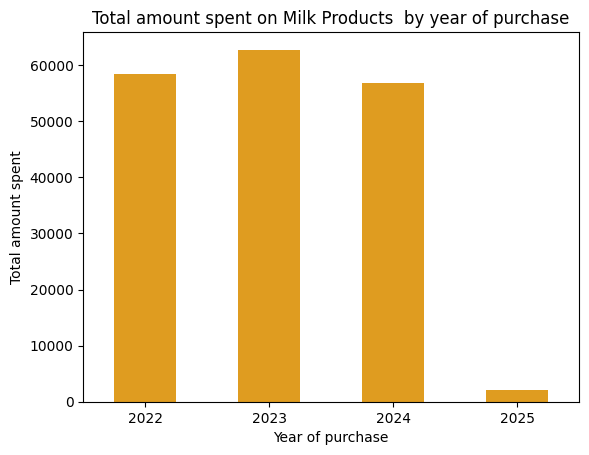

In [75]:
sns.barplot(x=df[(df["Category"]=="Milk Products")].groupby("Year")["Total Spent"].sum().index,y=df[(df["Category"]=="Milk Products")].groupby("Year")["Total Spent"].sum().values,width=0.5,color="Orange")
plt.xlabel("Year of purchase")
plt.ylabel("Total amount spent")
plt.title("Total amount spent on Milk Products  by year of purchase")

7. Patisserie                            

Text(0.5, 1.0, 'Total amount spent on Patisserie  by year of purchase')

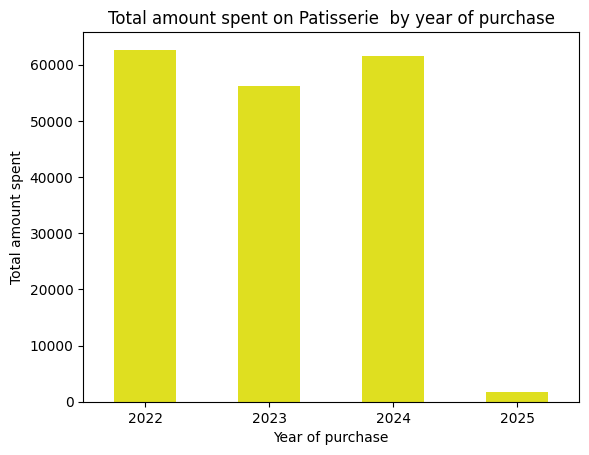

In [79]:
sns.barplot(x=df[(df["Category"]=="Patisserie")].groupby("Year")["Total Spent"].sum().index,y=df[(df["Category"]=="Patisserie")].groupby("Year")["Total Spent"].sum().values,width=0.5,color="Yellow")
plt.xlabel("Year of purchase")
plt.ylabel("Total amount spent")
plt.title("Total amount spent on Patisserie  by year of purchase")

**💡Insights:**

* 2025 has the lowest total amount spent on each category, leads to least sales.

In [81]:
df.to_csv("cleaned_dataset_retail_stores.csv")